## Lecture 9

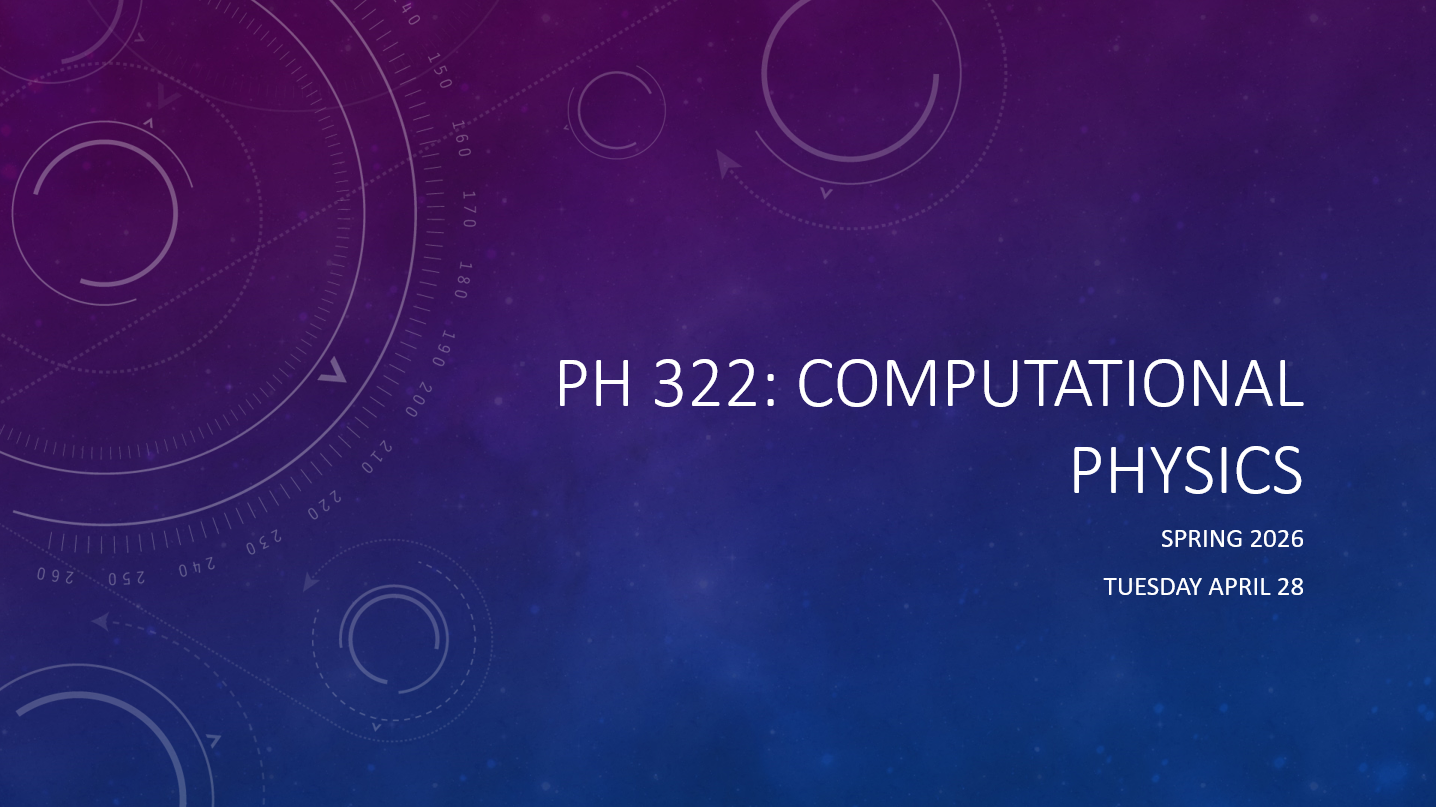

In [1]:
from IPython.display import Image, display
display(Image("G:\\My Drive\\Classes\\Ph322\\2026\\Lectures\\Figures\\header_lecture9.png"))

**Announcements**
* Still waiting on approval to change rooms.
* Midterm next week. I posted a study guide on Canvas in the Exams module. You are allowed two pages of notes, otherwise closed book/notes. All problems including coding problems will be written.

**Last class**
* Gaussian quadrature.
* Computing integrals over infinite ranges.
* Computing double integrals.



**Today**
* Numerical derivatives
* Forward differences
* Backward differences
* Central differences
* Approximation error on numerical derivatives
* Second derivatives
* Partial derivatives
* Derivatives of numerical data
* Using LOWESS to smooth data




## Derivatives

We next turn to numerical methods of finding derivatives.

The numerical method is taken from the standard definition of the derivative of a the function $f(x)$:

$$
\frac{df}{dx} = \lim_{\delta \to 0}\frac{f(x+\delta) - f(x)}{\delta}
$$

Though numerically we can't ever set $\delta$ to 0, we can make it as small as we like. Doing so, the derivative is calculated simply as:

$$
\frac{df}{dx} = \frac{f(x+h) - f(x)}{h}
$$

where $h$ is our interval width. 

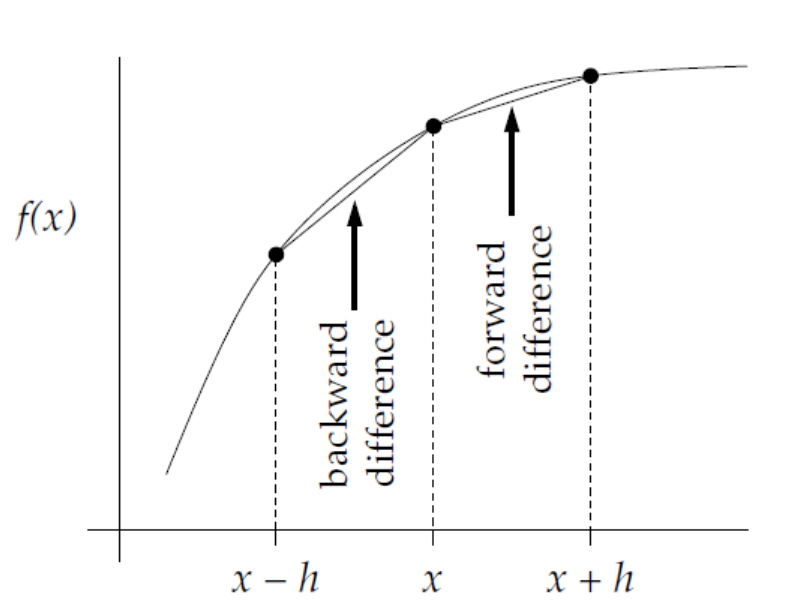

We can use the figure to understand the different ways we can calculate the derivative at $x$. 

The definition of the derivative as written gives us the *forward difference* as you can see from the figure, because we use a point forward of $x$, i.e. $x+h$ to calculate the derivative. 

We could also include the point backward of $x$ to calculate the slope, i.e. $x-h$. This is the *backward difference* and the derivative calculated from it is simply:

$$
\frac{df}{dx} = \frac{f(x) - f(x-h)}{h}
$$


Let's use both methods and calculate the derivative of $f(x) = x^4 - 2x + 1$ at $x=1$. The true derivative is 2. We will compare both derivatives to the analytic derivative using $h=1e-3$.  

In [28]:
# use forward and backward differences to calculate the derivative

# define our function
def f(x):
    return x**4-2*x+1

# define the analytic derivative to compare
def f1(x):
    return 4*x**3 - 2

# set our interval width
h = 1e-3

# set where we evaluate the derivative
x = 1

# calculate the true derivative using the analytic derivative
true = f1(x)

# now calculate using the forward difference
f_dfdx = (f(x+h) - f(x))/h
f_error= abs(100*(true-f_dfdx)/true)

# now calculate using backward difference
b_dfdx = (f(x) - f(x-h) )/h
b_error= abs(100*(true-b_dfdx)/true)

print(f"Analytic derivative: {f1(x):0.3f}")
print(f"Numerical derivative using forward difference: {f_dfdx:0.3f} +/- {f_error:0.2f}%")
print(f"Numerical derivative using backward difference: {b_dfdx:0.3f} +/- {b_error:0.2f}%")


Analytic derivative: 2.000
Numerical derivative using forward difference: 2.006 +/- 0.30%
Numerical derivative using backward difference: 1.994 +/- 0.30%


We get an error of around 0.3%. We see we get slightly different results from each method. Without thinking about it too much, it appears we want to make $h$ as small as we can, to get the most accurate result. 

Let's rerun the program using $h=1e-4$. When we do, the error decreases to 0.03%. 

Instead of testing out a bunch of $h$'s, let's plot the error of our numerical derivatives as a function of $h$:

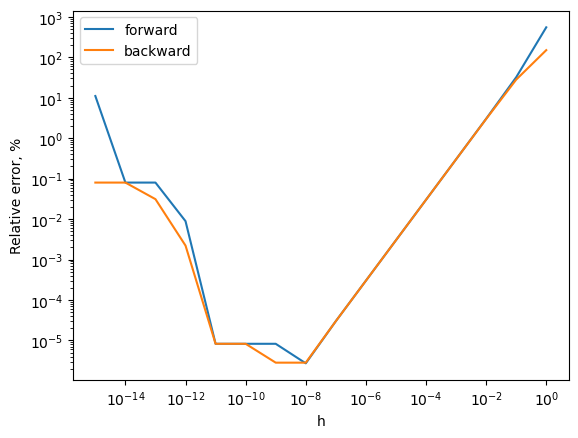

The mininum relative error is 2.72e-06%.


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# error using the forward difference
def forward(h,x, true):
    dfdx = (f(x+h) - f(x))/h
    #return abs(100*(true-dfdx)/true)
    return 100.*abs(true-dfdx)/true

# error using the backward difference
def backward(h,x, true):
    dfdx = (f(x) - f(x-h) )/h
    #return abs(100*(true-dfdx)/true)
    return 100.*abs(true-dfdx)/true

# define the analytic derivative to compare
def f1(x):
    return 4*x**3 - 2


# create a range of h in powers of ten, from 1 to 10^(-15)
h= -np.arange(0,16,1,float)
h = 10**h

x = 1
f_error = forward(h,x, true)
b_error = backward(h,x, true)
true = f1(x)


plt.plot(h, f_error, label="forward")
plt.plot(h, b_error, label="backward")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("h")
plt.ylabel("Relative error, %")
plt.legend()
plt.show()

print(f"The mininum relative error is {np.min(f_error):0.2e}%.")

These are interesting results.

For starters we don't see much difference between the forward and backward differences. Both produce about the same error across this wide range of h.

Secondly, and somewhat surprisingly, the error actually increases for interval widths smaller than $10^{-8}$. The most accurate results are when h $\sim 10^{-8}$.

Finally, even the best error isn't that great. The lowest relative error is of order $10^{-6}$% or an absolute error of order $10^{-8}$.  While this isn't awful, it's far from the numerical precision of rounding error. It is much worse than the accuracy we achieved with our numerical integration methods. 

## The error on the derivative

We can use a Taylor series expansion to determine the approximation error on the estimate of the derivative using the forward method.

The function $f(x)$ at a nearby point $x+h$ can we written;

$$
f(x+h) = f(x) + hf'(x) + \frac{1}{2}hf''(x) + ...
$$

Rearranging,  we can write the derivative of $f(x)$ as:

$$
f'(x) = \underbrace{\frac{f(x+h) - f(x)}{h}}_{\text{forward difference derivative}} - \underbrace{\frac{1}{2}hf''(x) + ...}_{\text{approximation error}}
$$



We see the first term is our approximation of the derivative using forward difference.  The approximation error of our estimate is the sum of the terms we omit. The biggest error term is proportional to $h$. So from this, we expect the approximation error to decrease as $h$ gets smaller. 

We do see this happen up to $h \sim 10^{-8}$. But why does the approximation error get bigger after this?

Well, the forward difference is the difference of two numbers. When $h$ is small, $f(x+h)$ and $f(x)$ are nearly the same. As we saw in chapter 4, taking the difference of two like floats produces a large relative rounding error. The smaller $h$ is, the bigger the relative rounding error.



$$
\text{approximation error } \propto h 
$$

$$
\text{rounding error } \propto \frac{1}{h}
$$

So we see there is a tug-of-war between the rounding error and approximation error when we numerically calculate derivatives. Decreasing $h$ decreases the approximation error but increases the rounding error.  Therefore there is some sweet spot for $h$ that minimizes total error.

The total error is the sum of the approximation error and rounding error. We can write it as:
$$
\epsilon = \text{approximation error + rounding error}
$$

$$
= \frac{1}{2}hf''(x) + 2Cf(x)/h
$$

where $C$ is our error constant $10^{-16}$.


We want to find the $h$ that minimizes the error, so we take the partial derivative of $\epsilon$ with respect to $h$, set it equal to zero, then solve for $h$.

$$
\frac{\partial \epsilon}{\partial h} = 0.
$$

Doing so, we find that the minimum error occurs at 

$$
h_{opt} = \sqrt{4C|\frac{f(x)}{f''(x)}|},
$$

where C is our error constant, $10^{-16}$. 

Substituting this back into the total error, we get:  


$$
\boxed{\epsilon = \sqrt{4C\left|f(x)f''(x)\right|}}.
$$


For the function we used above, $f(x)$ and $f''(x)$ are both of order 1, so the minimum error occurs for: 

$$
h_{opt} \sim \sqrt{(4)10^{-16}},
$$

or $~ 2\times 10^{-8}$ which is what we found above.  


The total error of the derivative is:

$$
\epsilon \sim \sqrt{(4)10^{-16}},
$$

or about $ ~ 2\times 10^{-8}$, which is again what we observed above.



### Central differences

There is one trick we can do to improve the accuracy of the derivative. That is to use the central difference to calculate the derivative instead of the forward or backward difference.

The central difference is defined:

$$
\frac{df}{dx} = \frac{f(x+h/2) - f(x-h/2)}{h},
$$

where the derivative at x is calculated at two points $h/2$ from $x$. 

To find the approximation error on the central difference derivative we write the Taylor Series expansion for both $f(x+h/2)$ and $f(x-h/2)$:

$$
f(x+h/2) = f(x) + \frac{1}{2}hf'(x) + \frac{1}{8}h^2f''(x) + \frac{1}{48}h^3f'''(x) + ...
$$
$$
f(x-h/2) = f(x) - \frac{1}{2}hf'(x) + \frac{1}{8}h^2f''(x) - \frac{1}{48}h^3f'''(x) + ...
$$


If we subtract the second from the first we find:


$$
f'(x) = \underbrace{\frac{f(x+h/2) - f(x-h/2)}{h}}_{\text{central difference}} -\underbrace{\frac{1}{24}h^2f'''(x) + ...}_{\text{approximation error}}
$$

Doing so, we see the first term is just the central difference method. But now we see the approximation error is proportional to $h^2$ not $h$, meaning it decreases faster than in either the forward or backward differences. If it decreases fast enough, we may be able to achieve a lower total error. 




Below I estimate the derivative of $f(x) = x^4 - 2x + 1$ at $x=1$ using all three methods and plot the errors vs. h. 


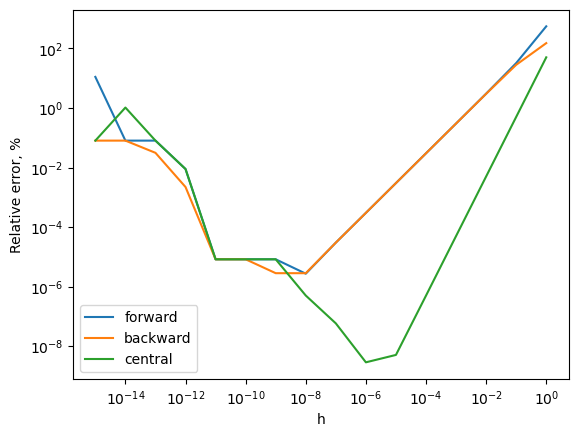

Minimum forward difference error = 2.723e-06%
Minimum backward difference error = 2.828e-06%
Minimum central difference error = 2.876e-09%


In [30]:
# compare error on the derivative using the central difference method

# define our function
def f(x):
    return x**4-2*x+1
    
# error using the forward difference
def forward(h,x, true):
    dfdx = (f(x+h) - f(x))/h
    return 100.*abs((true-dfdx)/true)

# error using the backward difference
def backward(h,x, true):
    dfdx = (f(x) - f(x-h) )/h
    return 100.*abs((true-dfdx)/true)

# error using the central difference
def central(h,x, true):
    dfdx = (f(x+h/2) - f(x-h/2) )/h
    return 100.*abs((true-dfdx)/true)

# define the analytic derivative to compare
def f1(x):
    return 4*x**3 - 2


# create a range of h in powers of ten, from 1 to 10^(-15)
h= -np.arange(0,16,1,float)
h = 10**h

x = 1
true = f1(x)
f_error = forward(h,x, true)
b_error = backward(h,x, true)
c_error = central(h,x, true)

plt.plot(h, f_error, label="forward")
plt.plot(h, b_error, label="backward")
plt.plot(h, c_error, label="central")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("h")
plt.ylabel("Relative error, %")
plt.legend()
plt.show()

print(f"Minimum forward difference error = {np.min(f_error):.3e}%")
print(f"Minimum backward difference error = {np.min(b_error):.3e}%")
print(f"Minimum central difference error = {np.min(c_error):.3e}%")

As expected we do see a smaller minimum error, an absolute error on the order of  $10^{-11}$, about 1000 times smaller than using either the forward or backward difference. 

We also see the minimum error occurs at a larger value of $h$ than either the forward or backward difference. This makes sense because the approximation error of the central difference in the Taylor expansion is proportional to $h^2$ not $h$, so the approximation error decreases faster.

Like the forward and backward differences, we can also derive equations for the optimal $h$ and the minimum error when using the central difference. The equivalent equations are:

$$
h = \left(24C \left|\frac{(f(x)}{f'''(x)} \right| \right)^{1/3}
$$

and

$$
\epsilon = \left(\frac{9} {8}C^2\left[f(x)\right]^2\left|f'''(x)\right|\right)^{1/3}
$$

For the function and example above,  we expect:

$$
h \sim ~((24)(10^{-16}))^{1/3} \sim 1.3\times 10^{-5},
$$

and 
$$
\epsilon \sim (\frac{9}{8}(10^{-16})^{2})^{1/3} \sim 2.2\times 10^{-11}.
$$

Both agree with our observations. 

### Second derivatives

Let's say we want to calculate the second derivatives of the function $f(x) =x^4-2x+1$.  Since a second derivative is just the derivative of the first derivative, we can simply apply the central difference method twice (we could also apply the forward or backward difference twice). But before we do, let's plot the analytical derivatives of the function so we can better understand what we are doing.

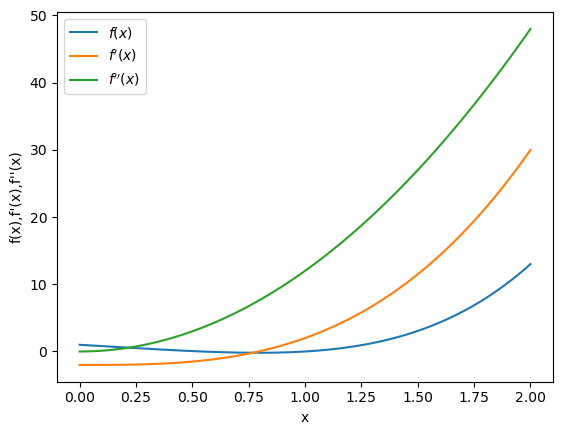

In [4]:
# plot f(x), f'(x), and f''(x) together.

import numpy as np
import matplotlib.pyplot as plt

# define f(x)
def ff(x):
    return x**4-2*x+1

# define f'(x)
def ff1(x):
    return 4*x**3 - 2

# define f''(x)
def ff2(x):
    return 12*x**2

# create a range of xvalues
xvalues = np.linspace(0,2,100)

# calculate f, f1, f2 for all x
f = ff(xvalues)
f1 = ff1(xvalues)
f2 = ff2(xvalues)

plt.plot(xvalues, f, label=r"$f(x)$")
plt.plot(xvalues, f1, label=r"$f'(x)$")
plt.plot(xvalues, f2, label=r"$f''(x)$")
plt.xlabel("x")
plt.ylabel("f(x),f'(x),f''(x)")
plt.legend()
plt.show()


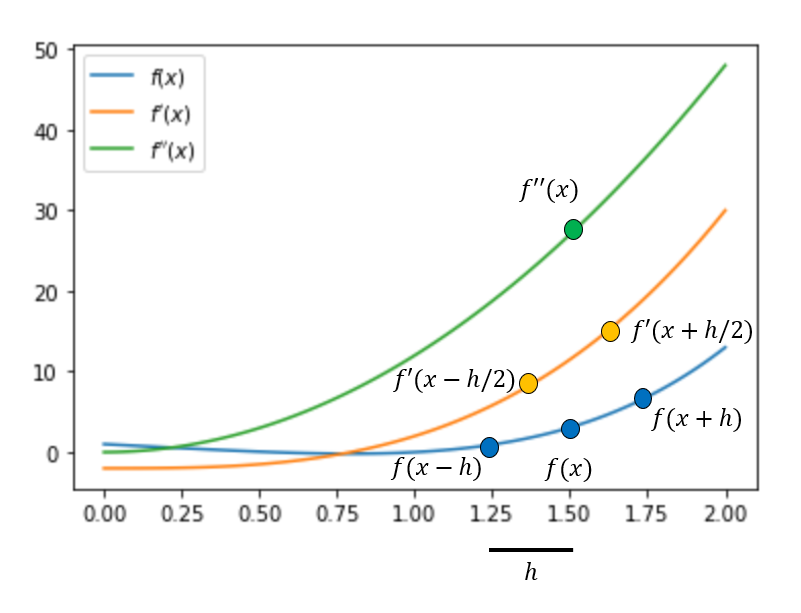

If we use the central difference to calculate the derivative, we see from the image above that the second derivative of $f(x)$ is:

$$
f''(x) = \frac{f'(x+h/2) - f'(x-h/2)}{h}
$$

where $h$ is the interval width.

From the image, we see the first derivatives are given by:

$$
f'(x-h/2) = \frac{f(x) -f(x-h)}{h}
$$

$$
f'(x+h/2) = \frac{f(x+h) -f(x)}{h}
$$

If we substitute these into the above equation for $f''(x)$ we get:

$$
f''(x) = \frac{ f(x+h) -f(x) - (f(x) -f(x-h))}{h^2} 
$$

$$
\boxed {= \frac{ f(x+h) -2f(x)  +f(x-h))}{h^2}}
$$

So this then is the **central difference approximation of the second derivative**. 

We will evaluate the second derivative of $f(x)=x^4-2x+1$ at $x=1.5$ using a central difference. 
Let's see how close we can get to the true value by calculating $f''(x)$ over a range of $h$. Here's the code:


The smallest absolute error on the second derivative over h is 1.35e-08.
This occurs for h = 1.00e-04.


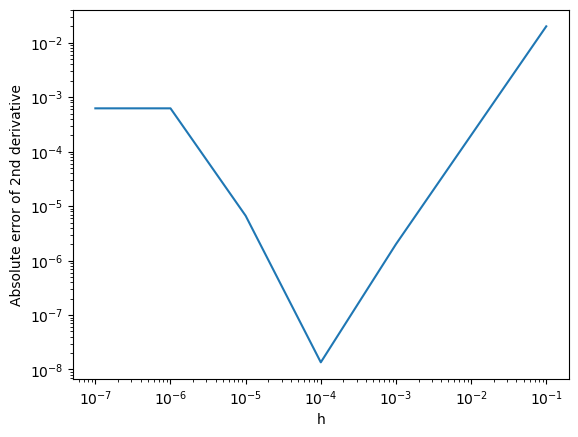

In [4]:
# plot f''(x) vs. h
import numpy as np
import matplotlib.pyplot as plt

# define function to differentiate
def f(x):
    return x**4-2*x+1

# central difference approximation to second derivative
def ff2(x,h):
    return (f(x+h) - 2*f(x) + f(x-h))/h**2
    
# true second derivative evaluated at x=1.5
true = 27

# x is where we evaluate the 2nd derivative
x = 1.5

# create a range of h that logarithmically decreases
h = -np.arange(1,8)
h = 10.0**h

# calculate the 2nd derivative at x (from above) for all interval widths
f2 = ff2(x, h)
abs_error = abs(true-f2)

# plot on a log-log scale
plt.plot(h, abs_error)
plt.xscale('log')
plt.yscale('log')
plt.xlabel("h")
plt.ylabel(r"Absolute error of 2nd derivative")

print(f"The smallest absolute error on the second derivative over h is {min(abs_error):0.2e}.")
print(f"This occurs for h = {h[np.argmin(abs_error)]:.2e}.")

We  see the most accurate estimate occurs at $h=10^{-4}$, and the error is $\sim 1\times10^{-8}$. 



Let's see if we can make sense of this error.

In the definition of the central difference above, we can write $f(x+h)$ and $f(x-h)$ in terms of a Taylor series expansion about $x$:

$$
f(x+h) = f(x) + hf'(x) + \frac{1}{2}h^2f''(x) + \frac{1}{6}h^3f'''(x) + \frac{1}{24}h^4f''''(x) ...
$$

$$
f(x-h) = f(x) - hf'(x) + \frac{1}{2}h^2f''(x) - \frac{1}{6}h^3f'''(x) + \frac{1}{24}h^4f''''(x)...
$$


If we add these two equations, and rearrange for $f''(x)$ we get:


$$
f''(x) = \underbrace{\frac{ f(x+h) -2f(x)  +f(x-h))}{h^2}}_{\text{central difference approximation}} - \frac{1}{12}h^2f''''(x) + ...
$$

We see the first term is just our central difference approximation to $f''(x)$. The second term is what we omit from our approximation, i.e, the approximation error. 

However, just as in the case of the  central difference approximation to the first derivative, the total error is the approximation error plus the rounding numerical error.

The rounding error in the numerator may be up to $4Cf(x)$ (C is the error constant $10^{-16}$), so the total error is:

$$
\epsilon = \frac{4C|f(x)|}{h^2} + \frac{1}{12}h^2|f''''(x)|
$$

Again we find the value of $h$ where the minimum error occurs by taking the partial derivative of $\epsilon$ and setting it equal to 0. 

The minimum value of $\epsilon$ occurs at:

$$
h =\left(48C\left|\frac{f(x)}{f''''(x)}\right|\right)^{1/4}
$$

and the total error at this $h$ is:

$$
\epsilon = (\frac{4}{3}C|f(x)f''''(x)|)^{1/2}
$$



Let's evaluate for our case.

For our example, $x=1.5$, $f(1.5) \sim 1$, $f''''(1.5)\sim 24$, 

giving $h\sim1.2\times 10^{-4}$ and $\epsilon\sim6\times10^{-8}$, 

which agrees with the minimum error and optimal $h$ we found above.


### Partial derivatives

We often encounter partial derivatives in physics.

For example the components of the electric field are defined as the partial derivatives of the electric potential $V$ along each dimension:

$$
E_x = - \frac{\partial }{\partial x}V(x,y,z)
$$

$$
E_y = - \frac{\partial }{\partial y}V(x,y,z)
$$

$$
E_z = - \frac{\partial }{\partial z}V(x,y,z)
$$

We can calculate the partial derivatives using the central difference just like regular derivatives. There really isn't much difference, other than we need to specify the values of the other variables we hold constant. 

We can can write the above partial derivatives using central differences, but we could also use forward or backward differences if needed:


$$
E_x = -\frac{V(x+h/2,y,z) - V(x-h/2,y,z)}{h}
$$

$$
E_y = -\frac{V(x,y+h/2,z) - V(x,y-h/2,z)}{h}
$$

$$
E_z = -\frac{V(x,y,z+h/2) - V(x,y,z-h/2)}{h}
$$

And similarly for partial second derivatives. 

### Practice Exercise - Numerical partial derivatives/electric field

Practice calculating partial derivatives by calculating the $x$-component of the electric field of a point charge with potential:

$$
V(r) = \frac{kq}{r},
$$

or written in Cartesian coordinates

$$
V(r) = \frac{kq}{(x^2+y^2+z^2)^{1/2}}.
$$

where $k$ is the electric constant $9\times 10^{9} Nm^2/C^2$, and $q$ is the charge of the point particle in coulombs.  

Place a $q=5nC$ point charge in the center of a $2\mu$m $\times$ $2\mu$m square region of the $xy$-plane ($z=0$).

Divide your square region into an $N\times N$ grid, where $N=1000$. 

Make a density plot of $E_x$.  Because the electric field blows up near the origin, you will need to set vmin, vmax in *imshow()* to visualize. Explain what you see.

#### Tip: ```numpy.meshgrid()```

It is often the case we want to create a grid or matrix of coordinate values. In this problem we want to create an $N\times N$ grid that spans $-1\mu$m $\le x \le 1\mu$m, and $-1\mu$m $\le y \le 1\mu$m.

One convenient way to do this is with the ```numpy``` function ```meshgrid()```. To use ```meshgrid()```,  first create two 1D arrays to hold the $x$ and $y$ coordinates. 

```
x = np.linspace(-1,1, 100)
y = np.linspace(-1,1, 100)
```
The then pass these arrays to ```meshgrid()``` to creates two 2D arrays that contain the $x$ and $y$ coordinates at each grid point.

```
X,Y = np.meshgrid(x,y)
```


An example better explains its use:

In [5]:
import numpy as np


# define the number of points along each dimension
Nx = 5
Ny = 3

# Define the x coordinate from say -2m to 2m 
x = np.linspace(-2, 2, Nx)  # Nx points from -2 to 2
# Define the y coordinate from say -1m to 1m 
y = np.linspace(-1, 1, Ny)  # Ny points from -1 to 1

# Create 2D grids 
X, Y = np.meshgrid(x, y)

# calculate r, the distance of each point to the origin
R = np.sqrt(X**2 + Y**2)

print("x array:\n", x)
print("y array:\n", y)
print("X grid:\n", X)
print("Y grid:\n", Y)
print("R grid:\n", R)



x array:
 [-2. -1.  0.  1.  2.]
y array:
 [-1.  0.  1.]
X grid:
 [[-2. -1.  0.  1.  2.]
 [-2. -1.  0.  1.  2.]
 [-2. -1.  0.  1.  2.]]
Y grid:
 [[-1. -1. -1. -1. -1.]
 [ 0.  0.  0.  0.  0.]
 [ 1.  1.  1.  1.  1.]]
R grid:
 [[2.23606798 1.41421356 1.         1.41421356 2.23606798]
 [2.         1.         0.         1.         2.        ]
 [2.23606798 1.41421356 1.         1.41421356 2.23606798]]


Use **numpy.meshgrid()** in your code below.

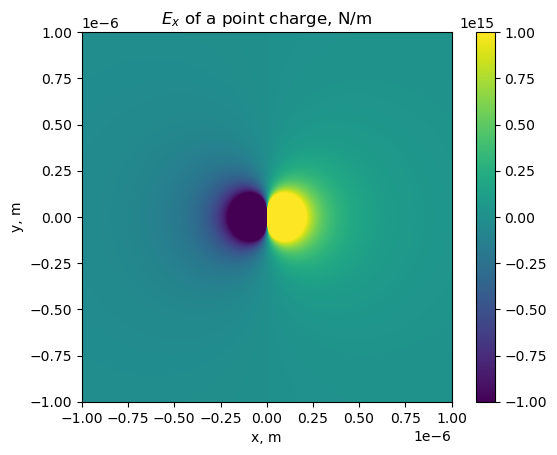

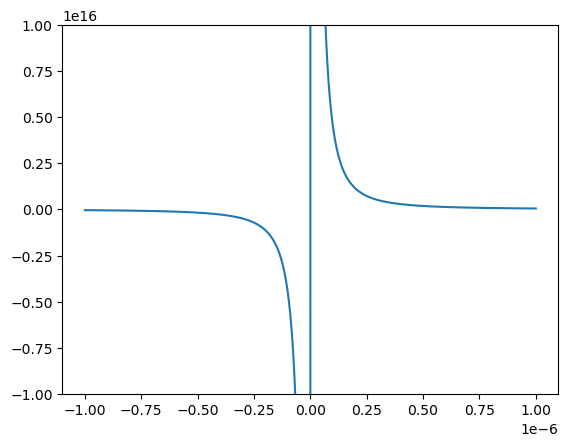

In [11]:
# practice exercise - calculate partial derivatives and the electric field 



### Taking derivatives of measured data

It is often the case we wish to calculate derivatives of a discrete data set, for example a set of measurements.

Let's take a look at some real measurements. The code below plots data from the famous Keeling Curve. The Keeling Curve is the continuous record of carbon dioxide (CO$_2$) measurements taken from Mauna Loa, Hawaii dating back to the 1950's. They clearly show the increase in CO2 since this time. The data file "monthly_in_situ_co2_mlo_2024.txt" is in Canvas/Modules/Data and Python files.


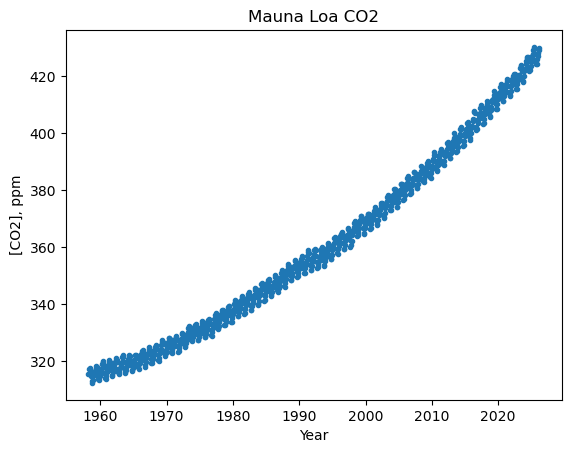

In [4]:
# numerical derivative of measured data

import numpy as np
import matplotlib.pyplot as plt

# directory path to file
path = "G:\\My Drive\\Classes\\Ph322\\Data files\\"
file = "monthly_in_situ_co2_mlo_2026.txt"

data = np.loadtxt(path+file)
#data = np.loadtxt(file)
# load in the file "monthly_in_situ_co2_mlo.txt"
# col 2 contains date in units of days
day = data[:,2]
# col 3 contains date in units of years
date = data[:,3]
co2 = data[:,4]

plt.plot(date, co2, '.')
plt.xlabel("Year")
plt.ylabel("[CO2], ppm")
plt.title("Mauna Loa CO2")
plt.show()


We can zoom in on a time period and see the annual peaks and valleys of CO2:

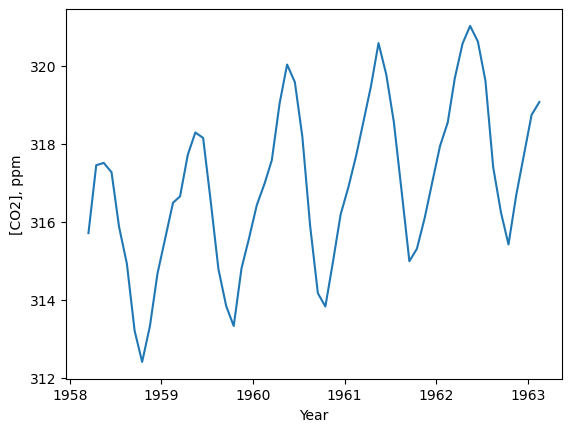

In [5]:
# plot a  5-year subsample
plt.plot(year[:60], co2[:60], '-')
plt.xlabel("Year")
plt.ylabel("[CO2], ppm")
plt.show()

We see that CO2 is drawn down during the northern hemisphere summer and peaks during the NH winter. This pattern emerges from the photosynthesis and respiration of the biosphere. As the biosphere "breathes in", CO2 decreases, and when it "breathes out" it increaes. The pattern is reflective of the NH seasons because the majority of the global landmass, hence biosphere, is located in the NH.

Absent the release of CO2 from human activites, we would expect the peaks and valleys be near constant from year. But the graph shows that on average the maximum peak each year increases, with some exceptions.

Climate scientists are often interested in taking the derivative of these measurements, since the derivative of a time series, gives us the trend. And in the case of CO2, the trend is an indicator of how CO2 emissions are changing over time. 

Since **this is a discrete time series not continuous**, we can't directly calculate derivatives using the central difference since we don't have data between the times. Therefore we must use either the **forward or backward difference**. 

It doesn't matter which we use, but note if we use the forward difference we can calculate derivatives only up to time $t_{N-1}$, where $N$ is number of data,  since we need the measurement at time $t_N$ to calculate the derivative at time  $t_{N-1}$. Likewise if we use the backward difference our first derivative is at time $t_2$ not $t_1$. We may wish to use different methods at the endpoints. 

Below we calculate the derivatives using backward differences.  

The script allows us to change the interval width $h$. If we set $h=1$, meaning we are calculating the derivative using measurements spaced 1 month part, the resulting derivatives or trends are quite noisy.

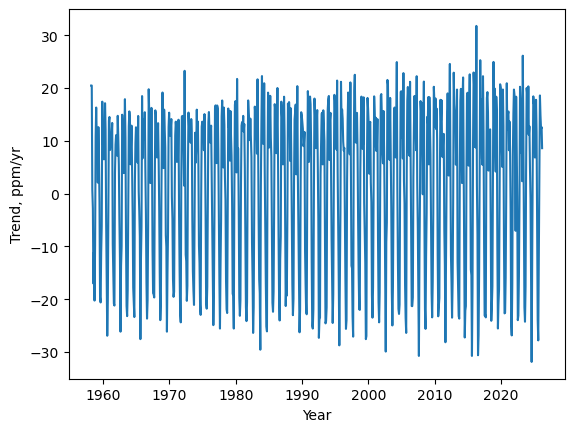

In [18]:
# use backward difference to calculate derivative

# the data are spaced monthly. h is the interval width in months.
h = 1 # number of time steps to calculate the derivative over, in this case 1 month
trend = np.empty([len(year)])

# use backward difference method to calculate derivative (trend)
# units of ppm/year

# find the number of data points
N = len(year)

# start index at h not zero because backward difference at t=i, requires t{i-h}
for t in range(h,N):
    trend[t] = (co2[t]-co2[t-h])/(year[t]-year[t-h])
    
# use forward difference to estimate trend at first time step
trend[0] = (co2[1]-co2[0])/(year[1]-year[0])

plt.plot(year, trend)
plt.xlabel("Year")
plt.ylabel("Trend, ppm/yr")
plt.show()

We see the derivatives are quite noisy. This makes sense because our interval width is short, and the seasonal trend dominates any long-term trends. 

To improve this, we can of course make our interval width longer. And specifically for this measurement record, since we know there is a 12-month seasonal cycle that we'd like to smooth over, we can make our interval width 12 months, or h=12. 

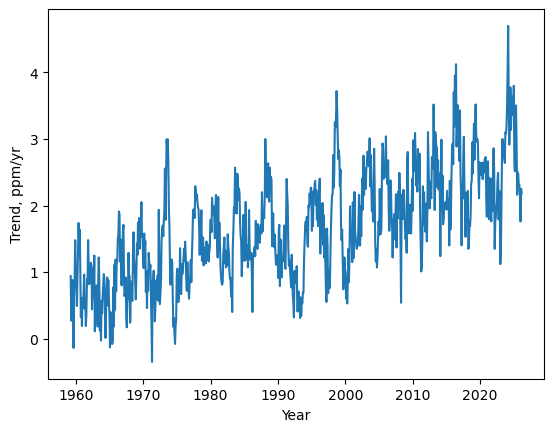

In [19]:
# use backward difference to calculate derivative

# the data are spaced monthly. h is the interval width in months.
h = 12 # interval, months
trend = np.empty([len(year)])

# use backward difference method to calculate derivative (trend)
# units of ppm/year

# find the number of data points
N = len(year)
# start index at h not zero because backward difference at t=i, requires t{i-h}
for t in range(h,N):
    trend[t] = (co2[t]-co2[t-h])/(year[t]-year[t-h])
    
plt.plot(year[h:], trend[h:])
plt.xlabel("Year")
plt.ylabel("Trend, ppm/yr")
plt.show()

This is much more informative. Now we have removed the trends from the seasonal cycle (notice almost all trends are positive), so what remains are the changes from year to year. 

Some interesting features emerge. First, there is an overall upward increase in the trend. This means that the rate we are emitting CO2 has been increasing over this period.

We see there are years with paricularly high emission rates, e.g. 1997-1998. This was a strong El Nino year associated with large tropical forest fires. We also see a dip around 1992. This coincides with the eruption of Mt. Pinatubo which led to a year of global cooling from sulphate aerosols in the stratosphere. Interestingly, the eruption led to lower CO2 levels not higher as we might expect from decreased sunlight and photosynthesis.

We also see smaller trends during the Covid-era years. 



### Smoothing the data

Another way we could reduce the noisy time series of derivatives is to first fit our raw data with a smooth curve, then differentiate the smooth curve.

A popular to smooth data is **LOWESS**, or *locally weighted scatterplot smoothing*. LOWESS is a regression method where low-order polynomials (typically quadratics) are fit to samples of data around every data point using linear least squares regression. The data point is replaced with the fit at that point. 

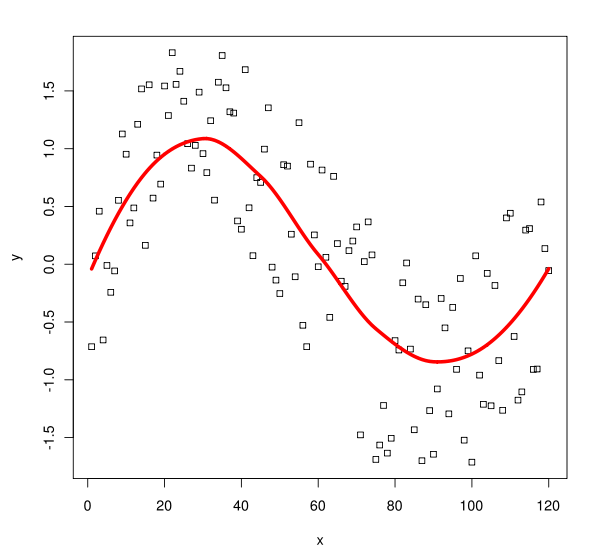

The resulting lowess curve is a smoothed curve through the original data points. Users can specify how many data points are to be included in each fit. The larger the number of data points, the smoother the lowess curve will be.

You can access a lowess function through the API *statsmodels.api*. You will likely need to install the *statsmodels* module to your Python distribution. 

The standard way to import the API and call the lowess function is:

```
import statsmodels.api as sm

# call the lowess function
output = sm.nonparametric.lowess()
```

You can find a full description of the lowess function at https://www.statsmodels.org/devel/generated/statsmodels.nonparametric.smoothers_lowess.lowess.html.

We will look at just a few of the arguments and keywords we can set in the function:

```
lowess(Y, X, frac, return_sorted=False)
```

*Y* is a 1-D numpy array that holds our y-values.

*X* is a 1_D numpy array that holds our x-values.

*frac* is the smoothing parameter, it determines the number of data points to use in each regression. The number of data points is equal to

$
\text{frac} \times N,
$

where $N$ is the total number of data points in the data set. The larger *frac* is the more data points will be used in each regression which produces a smoother curve. It typically takes some trial and error to find the best value for *frac*.

*return_sorted* If set to True (default), then the returned array is sorted by X and has missing (nan or infinite) observations removed. If False, then the returned array is in the same length and the same sequence of observations as the input array. Typically set to False. If return_sorted is set to False, the function returns a 1-D array of the fit data values, otherwise it returns a 2-D array that also contains the sorted X values.

Let's try it out. 

Our data set contains 817 data points. Perhaps we want each regression to be performed on 12 months of data. If so, then frac=12/817 =0.015

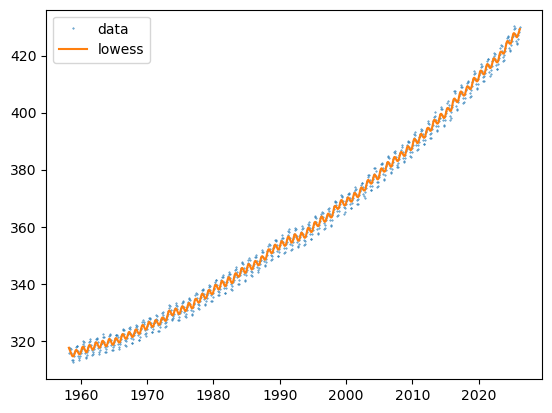

In [20]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Smooth the CO2 using LOWESS. frac determines how smooth the fit is. Increase frac to increase smooth.
smooth_LOWESS = sm.nonparametric.lowess(co2, year, frac=0.015, return_sorted=False)

plt.plot(year,co2, '.', label="data", ms=0.8)
plt.plot(year, smooth_LOWESS, label="lowess")
plt.legend()
plt.show()

We see this choice of *frac* still retains the seasonal cycle. Let's increase *frac* until the seasonal cycles are smoothed out:

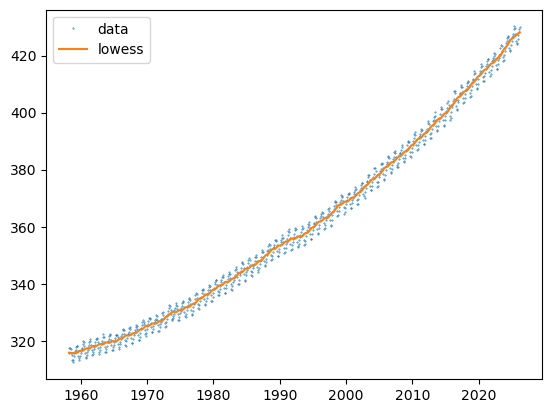

In [21]:
# Smooth the CO2 using LOWESS. frac determines how smooth the fit is. Increase frac to increase smooth.
smooth_LOWESS = sm.nonparametric.lowess(co2, year, frac=0.03, return_sorted=False)

plt.plot(year,co2, '.', label="data", ms=0.8)
plt.plot(year, smooth_LOWESS, label="lowess")
plt.legend()
plt.show()

A value of $frac=0.03$ looks pretty good. It passes through our data points and captures the yearly trends. Now we differentiate the smoothed lowess fit, not the data themselves:

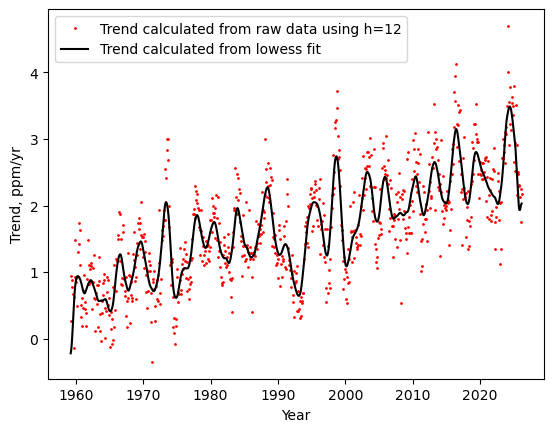

In [26]:
# differentiate the LOWESS fit

# the data are spaced monthly. h is the interval width in months.
h = 12 # interval, months
trend_lowess = np.empty([len(year)])


# use backward difference method to calculate derivative (trend)
# units of ppm/year

# find the number of data points
N = len(year)
# start index at h not zero because backward difference at t=i, requires t{i-h}
for t in range(h,N):
    trend_lowess[t] = (smooth_LOWESS[t]-smooth_LOWESS[t-h])/(year[t]-year[t-h])
    

plt.plot(year[h:], trend[h:], 'ro', ms=1.0, label="Trend calculated from raw data using h=12")
plt.plot(year[h:], trend_lowess[h:], 'k',label="Trend calculated from lowess fit")
plt.legend()
plt.xlabel("Year")
plt.ylabel("Trend, ppm/yr")
plt.show()

We see the trends are much smoother now. The peaks and valleys indicate real changes in the year-to-year rates as which CO2 is growing in the atmosphere. We also see that over this period of time that the average trend is increasing, indicating not only is CO2 continuing to increase, its rate of growth is also increasing. 